In [1]:
# importing libraries

import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Measuring the Measurement: Variation, Samples and the Precision of an Estimate

This notebook explores the relationship between population parameters and  sample statistics through simulation. We will build intuition for the Central Limit Theorem, the Standard Error of the Mean (SEM), and how sample size affects the precision of our estimates.

All results are derived from a simulated population, so we always know the ground truth and can check how well our estimates recover it.

## The Population

We simulate a population of around 7 million heights (in cm). In a real scenario you would never have access to the entire population, but here we do, deliberately, so we can treat the values computed directly from this dataset as the true parameters.

Two things to note:
- `pop_mean` and `pop_std` are computed from the data, not taken from the generating parameters. The dataset *is* the population.
- `ddof=0` for the population std: no correction needed when you have every single observation.

In [2]:
rng = np.random.default_rng(seed=42)

pop_size = 7_194_452
population = rng.normal(loc=170, scale=10, size=pop_size)

pop_mean = population.mean()
pop_std  = population.std(ddof=0)

print(f"Population size : {pop_size:,}")
print(f"True mean       : {pop_mean:.4f} cm")
print(f"True std        : {pop_std:.4f} cm")

Population size : 7,194,452
True mean       : 170.0042 cm
True std        : 9.9975 cm


## 2. Visualising the population

Before pretending we do not know the population parameters, let us look at the full distribution. The histogram shows the shape of the data, and  the vertical line marks the true mean.

The population is generated from a Gaussian model, so the full distribution is essentially normal.We  will rely on throughout the notebook when drawing and interpreting samples.

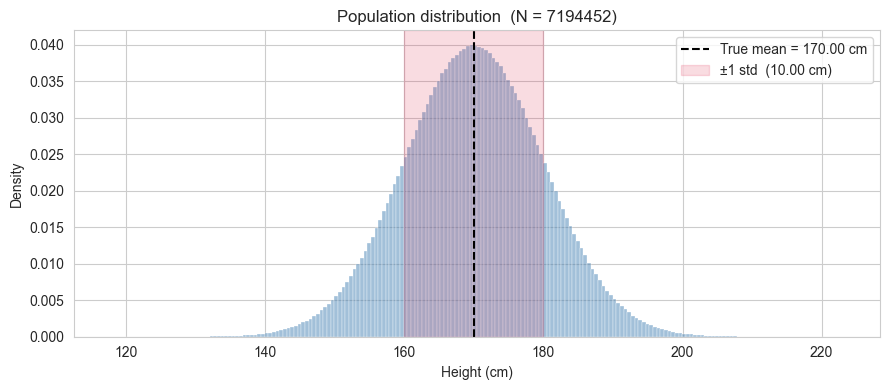

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.histplot(population, bins=200, stat="density",
             color="steelblue", alpha=0.5, ax=ax)

ax.axvline(pop_mean, color="black", linestyle="--", linewidth=1.5,
           label=f"True mean = {pop_mean:.2f} cm")

ax.axvspan(pop_mean - pop_std, pop_mean + pop_std,
           alpha=0.15, color="crimson",
           label=f"±1 std  ({pop_std:.2f} cm)")

ax.set_xlabel("Height (cm)")
ax.set_ylabel("Density")
ax.set_title(f"Population distribution  (N = {len(population)})")
ax.legend()

plt.tight_layout()
plt.show()

## 3. Drawing a single sample

We now pretend we do not know `pop_mean` and `pop_std`. We draw a sample  of `n` observations from the population and compute the sample mean and sample standard deviation.

A few things to keep in mind:

- The sample mean is our best guess of the true mean from this one draw.
- The sample std is computed with `ddof=1` (Bessel's correction). The reason will be explained in detail later (for now, just note that when working with a sample rather than the full population, we divide by `n-1` instead of `n`)
- These two numbers will change every time we draw a new sample. How much they change, and in what direction, is exactly what we will study next.


**A note on sampling with and without replacement.**
Here we sample *without* replacement (`replace=False`): once an individual is selected, they cannot be selected again. This is the natural choice when sampling from a finite, well-defined population because in practice you would not measure the same person twice.

Sampling *with* replacement (`replace=True`) is used in two distinct contexts:

1. **Theoretical convenience.** Classical statistical theory (including the Central Limit Theorem in its standard form) is derived under the assumption of independent and identically distributed (i.i.d.) observations. Draws with replacement are exactly i.i.d. by construction. Draws without replacement are not, because each draw changes the composition of the remaining pool. When the  population is very large relative to the sample size (as it is here: 30 out of 7 million), the dependence introduced by sampling without replacement is negligible and the i.i.d. approximation holds to an excellent degree. This is formalised by the *finite population correction factor*, which quantifies how much the variance of the sample mean is reduced when sampling without  replacement: it equals `1 - n/N`, which here is `1 - 30/7,000,000 ≈ 1`. The correction is essentially invisible at this scale. Precisely, the variance of the sample mean when sampling without replacement is given by:

    $$\text{Var}(\bar{x}) = \frac{\sigma^2}{n} \times \frac{N-n}{N-1}$$

    where the term $\frac{N-n}{N-1}$ is the **finite population correction factor**. In our case, with $n=30$ and $N \approx 7,000,000$, this factor equals approximately $0.9999996$, which is why the correction is essentially invisible.


2. **The bootstrap.** Resampling *with* replacement from an observed sample is the foundation of the bootstrap method (Efron, 1979). The key idea is that the observed sample is treated as a proxy for the population, and repeated resampling from it with replacement simulates the variability one would see across repeated draws from the true population. In this context, replacement is not an approximation but it is the mechanism that makes the method work.

For this notebook, `replace=False` is the right choice. The i.i.d. assumption holds to an excellent approximation given the ratio of sample size to population size, so the theoretical results we derive will apply without modification.

In [4]:
n = 30

sample = rng.choice(population, size=n, replace=False)

sample_mean = sample.mean()
sample_std  = sample.std(ddof=1)

print(f"Sample size  : {n}")
print(f"Sample mean  : {sample_mean:.4f} cm  (true mean : {pop_mean:.4f} cm)")
print(f"Sample std   : {sample_std:.4f} cm  (true std  : {pop_std:.4f} cm)")
print(f"Difference in mean : {abs(sample_mean - pop_mean):.4f} cm")

Sample size  : 30
Sample mean  : 171.8113 cm  (true mean : 170.0042 cm)
Sample std   : 8.9356 cm  (true std  : 9.9975 cm)
Difference in mean : 1.8071 cm


## 4. Repeating the draw: the sampling distribution of the mean

A single sample gives us one estimate of the mean. But if we repeated the study, i.e. drawing a fresh sample of $n$ observations each time, we would get a different estimate every time. The collection of all these estimates forms the *sampling distribution of the mean*.

This is the central object of the Central Limit Theorem (CLT), which states:

> Regardless of the shape of the population distribution, the sampling distribution of the mean approaches a Gaussian distribution as $n$ increases, with mean equal to the population mean and standard deviation equal to $\dfrac{\sigma}{\sqrt{n}}$.

This last quantity, $\sigma / \sqrt{n}$, is the **Standard Error of the Mean (SEM)**. It measures how much the sample mean is expected to vary across repeated draws. It is not a measure of spread in the population (that is $\sigma$), but a measure of the precision of our estimate of the population mean.

We will now verify this empirically. We repeat the draw $n_{\text{repeats}}$ times, collect the sample means, and compare their distribution to what the CLT predicts.

In [5]:
n_repeats = 10_000

sample_means = np.array([
    rng.choice(population, size=n, replace=False).mean()
    for _ in range(n_repeats)
])

# theoretical prediction from the CLT
sem_true = pop_std / np.sqrt(n)

# empirical counterparts from the simulation
simulated_mean_of_means = sample_means.mean()
# ddof=1 computes the unbiased estimator of the standard deviation,
# which is the right choice for comparing to the CLT prediction
simulated_sem            = sample_means.std(ddof=1)

comparison = pd.DataFrame({
    "CLT prediction" : [pop_mean,  sem_true],
    "simulation"     : [simulated_mean_of_means, simulated_sem]
}, index=["mean of sample means", "std of sample means (SEM)"])

comparison.round(4)

,CLT prediction,simulation
mean of sample means,170.0042,169.9880
std of sample means (SEM),1.8253,1.8261


The column *CLT prediction* is not a result of the simulation but it is what the Central Limit Theorem tells us to expect *before running a single draw*. Given that we know the true population standard deviation $\sigma$ and the sample size $n$, the CLT predicts that the standard deviation of the sampling distribution of the mean will be exactly $\sigma/\sqrt{n}$.

The column *Simulation* is what we actually observed across the 10000 repeated draws. The fact that the two numbers are very close is not a coincidence: it is the CLT at work. The simulation is confirming the theoretical prediction empirically.

Note also that the mean of the 10000 sample means is very close to the true population mean. This is the property of *unbiasedness*: on average, the sample mean neither overestimates nor underestimates the population mean.

**Technical note on ddof:** We compute `simulated_sem` using `ddof=1`, which gives the unbiased estimator of the sampling distribution's standard deviation. This is the appropriate choice when comparing empirical results to the CLT prediction, because we are estimating a population parameter (the true SEM) from a finite sample of means.

## 5. Visualising the sampling distribution

The table in the previous cell showed that the numbers agree. Now we look at the full shape of the sampling distribution of the mean and compare it to the Gaussian that the CLT predicts.

Two things to look for in the plot:

- The histogram of the 10,000 sample means should be well described by a Gaussian with mean $\mu$ and standard deviation $\dfrac{\sigma}{\sqrt{n}}$.
- The spread of this distribution is much narrower than the population distribution we saw earlier. This is expected: the SEM $\dfrac{\sigma}{\sqrt{n}}$ is always smaller than $\sigma$, and shrinks as $n$ grows.

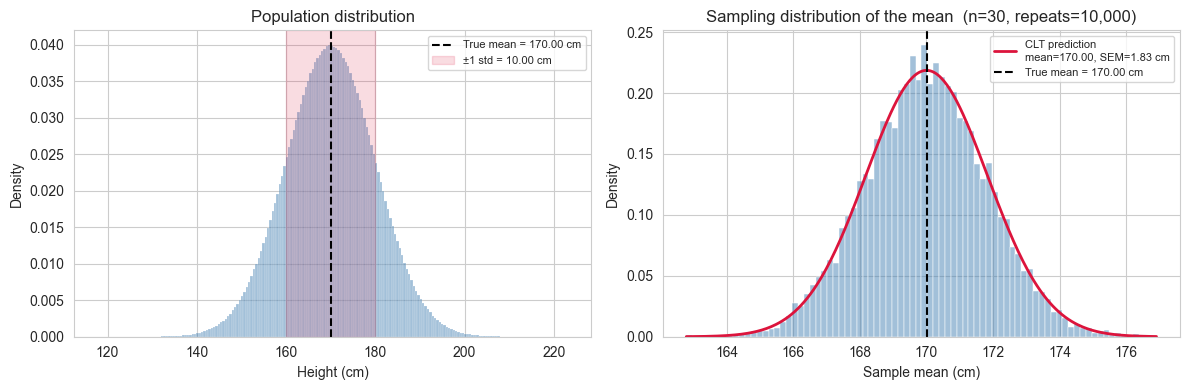

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: population
sns.histplot(population, bins=200, stat="density",
             color="steelblue", alpha=0.5, ax=axes[0])
axes[0].axvline(pop_mean, color="black", linestyle="--", linewidth=1.5,
                label=f"True mean = {pop_mean:.2f} cm")
axes[0].axvspan(pop_mean - pop_std, pop_mean + pop_std,
                alpha=0.15, color="crimson",
                label=f"±1 std = {pop_std:.2f} cm")
axes[0].set_title("Population distribution")
axes[0].set_xlabel("Height (cm)")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# Right panel: sampling distribution of the mean
sns.histplot(sample_means, bins=80, stat="density",
             color="steelblue", alpha=0.5, ax=axes[1])

x_range = np.linspace(sample_means.min(), sample_means.max(), 300)
axes[1].plot(x_range, stats.norm.pdf(x_range, pop_mean, sem_true),
             color="crimson", linewidth=2,
             label=f"CLT prediction\nmean={pop_mean:.2f}, SEM={sem_true:.2f} cm")
axes[1].axvline(pop_mean, color="black", linestyle="--", linewidth=1.5,
                label=f"True mean = {pop_mean:.2f} cm")
axes[1].set_title(f"Sampling distribution of the mean  (n={n}, repeats={n_repeats:,})")
axes[1].set_xlabel("Sample mean (cm)")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Two bell curves, two different meanings.**

The plot on the right can create a subtle confusion: it looks like the population distribution on the left, just narrower. But the two curves describe completely different things.

- The left panel shows the distribution of **individual heights** in the population. Its spread, measured by $\sigma$, tells us how much a single randomly chosen person is likely to differ from the average. Roughly 68% of all people in the population have a height within $\pm 1\sigma$ of $\mu$. This is a statement about the **data**.

- The right panel shows the distribution of **sample means**: each point in that histogram is not a person's height, but the average height computed from a sample of $n$ people. Its spread, measured by the SEM $\\sigma/\sqrt{n}$, tells us how much our estimate of the mean is likely to differ from the true mean if we repeated the study. Roughly 68% of all sample means fall within $\pm 1$ SEM of $\mu$. This is a statement about the **precision of a measurement**.

Both quantities share the same mathematical structure (a standard deviation of some distribution) but they answer entirely different questions:

| | $\sigma$ | SEM $= \dfrac{\sigma}{\sqrt{n}}$ |
|---|---|---|
| **What varies?** | Individual observations | Sample means |
| **What does it measure?** | Spread in the population | Precision of the mean estimate |
| **Depends on $n$?** | No | Yes — shrinks as $n$ grows |

This distinction matters in practice. Reporting $\sigma$ when you mean SEM  (or vice versa) is a common and consequential mistake in applied research, because one is a property of the population and the other is a property of your measurement process.

## 6. The effect of sample size on the precision of the mean estimate

We established that the SEM $= \sigma / \sqrt{n}$ shrinks as $n$ grows. This means that larger samples give more precise estimates of the population mean. But how much more precise, and can we see it directly in the simulation?

The relationship is not linear. Doubling the sample size does not halve the SEM but it reduces it by a factor of $1 / \sqrt{2} \approx 0.71$. More generally, to reduce the SEM by a factor of $k$, you need to increase the sample size by a factor of $k^2$. This has practical consequences: improving precision becomes increasingly expensive as the required precision grows.

We will now repeat the sampling experiment for a range of sample sizes and compare the simulated spread of sample means to the CLT prediction  $\sigma / \sqrt{n}$ at each value of $n$.

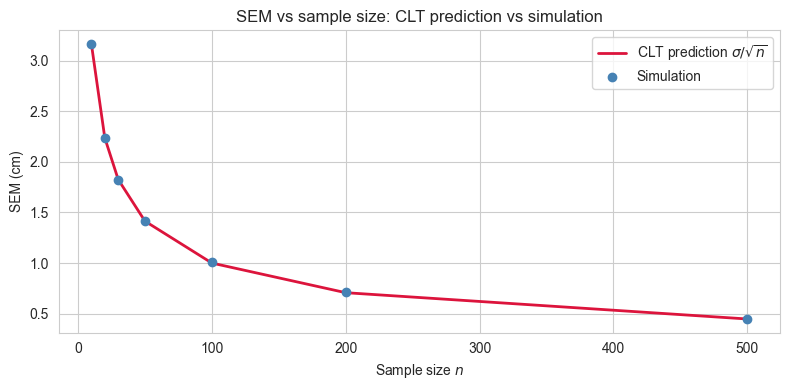

,CLT prediction,simulation,difference
sample size,,,
10,3.1615,3.1629,0.0014
20,2.2355,2.2373,0.0018
30,1.8253,1.8173,0.0079
50,1.4139,1.4171,0.0033
100,0.9997,1.0097,0.0100
200,0.7069,0.7090,0.0020
500,0.4471,0.4490,0.0019


In [7]:
sample_sizes = [10, 20, 30, 50, 100, 200, 500]
n_repeats    = 10_000

simulated_sems = []
clt_sems       = []

for sample_size in sample_sizes:
    means = np.array([
        rng.choice(population, size=sample_size, replace=False).mean()
        for _ in range(n_repeats)
    ])
    simulated_sems.append(means.std(ddof=1))
    clt_sems.append(pop_std / np.sqrt(sample_size))

# Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(sample_sizes, clt_sems, color="crimson", linewidth=2,
        label="CLT prediction $\\sigma / \\sqrt{n}$")
ax.scatter(sample_sizes, simulated_sems, color="steelblue", zorder=5,
           label="Simulation")

ax.set_xlabel("Sample size $n$")
ax.set_ylabel("SEM (cm)")
ax.set_title("SEM vs sample size: CLT prediction vs simulation")
ax.legend()

plt.tight_layout()
plt.show()

results = pd.DataFrame({
    "sample size"      : sample_sizes,
    "CLT prediction"   : clt_sems,
    "simulation"       : simulated_sems,
    "difference"       : [abs(c - s) for c, s in zip(clt_sems, simulated_sems)]
})

results = results.set_index("sample size").round(4)
results

## 7. Estimating the population standard deviation

So far we have used the population standard deviation $\sigma$ directly in the SEM formula. In practice, $\sigma$ is unknown, just like $\mu$, and must be estimated from the sample.

The natural candidate is the sample standard deviation. Given a sample $x_1, x_2, \ldots, x_n$, the sample standard deviation is:

$$s = \sqrt{\dfrac{\sum_{i=1}^{n}(x_i - \bar{x})^{2}}{n-1}}$$

The denominator is $n-1$, not $n$: this is **Bessel's correction**.

**Why $n-1$ and not $n$?**

When we compute the sample mean $\bar{x}$ from the data, we are using the  data twice: once to estimate the mean, and once to estimate the spread around it. This introduces a subtle bias (the deviations $(x_i - \bar{x})$ are computed around the sample mean, not the true mean $\mu$). Because $\bar{x}$ is itself derived from the same data, the deviations tend to be slightly smaller than the true deviations around $\mu$. Dividing by $n-1$ instead of $n$ corrects for this, making $s^{2}$ an unbiased estimator of $\sigma^{2}$.

Concretely, this means that on average across many repeated samples, $s^{2}$ will equal $\sigma^{2}$. Note that this unbiasedness applies to the variance $s^{2}$, not to $s$ itself. The standard deviation has a small remaining bias that only becomes negligible for large $n$.

**How good is the estimate?**

Just like the sample mean varies from draw to draw, so does $s$. We can use the same simulation approach to ask: across 10,000 repeated draws, how close is $s$ to the true $\sigma$ on average? And how does this depend on $n$?

**Estimating the SEM in practice**

Since $\sigma$ is unknown, we cannot compute the true SEM $\sigma / \sqrt{n}$ directly. Instead, we estimate it using the sample standard deviation:

$$
SEM \approx \frac{s}{\sqrt{n}} 
$$

This is the formula used in real data analysis when you want to report the precision of your mean estimate. It tells you how much your sample mean is likely to vary across repeated studies.

In [8]:
sample_sizes = [10, 20, 30, 50, 100, 200, 500]
n_repeats    = 10_000

mean_of_s        = []   # average sample std across repeats
std_of_s         = []   # variability of the sample std across repeats

for sample_size in sample_sizes:
    sample_stds = np.array([
        rng.choice(population, size=sample_size, replace=False).std(ddof=1)
        for _ in range(n_repeats)
    ])
    mean_of_s.append(sample_stds.mean())
    std_of_s.append(sample_stds.std(ddof=1))

results_std = pd.DataFrame({
    "sample size"          : sample_sizes,
    "true sigma"           : [pop_std] * len(sample_sizes),
    "mean of s"            : mean_of_s,
    "bias (mean s - sigma)": [m - pop_std for m in mean_of_s],
    "variability of s"     : std_of_s
})

results_std = results_std.set_index("sample size").round(4)
results_std

,true sigma,mean of s,bias (mean s - sigma),variability of s
sample size,,,,
10,9.9975,9.7329,-0.2646,2.3415
20,9.9975,9.8546,-0.1429,1.6043
30,9.9975,9.9120,-0.0855,1.3171
50,9.9975,9.9236,-0.0738,1.0010
100,9.9975,9.9629,-0.0345,0.7077
200,9.9975,9.9968,-0.0007,0.4998
500,9.9975,9.9922,-0.0053,0.3168


## 8. A note on non-Gaussian populations

Throughout this notebook we assumed that the population is Gaussian. This made the exposition clean: the sample mean is exactly Gaussian for any $n$, and the CLT predictions hold without approximation.

In practice, populations are rarely perfectly Gaussian. Heights are a reasonable approximation, but many quantities of interest (income, reaction times, insurance claims, city populations) are heavily skewed or have thick tails.

The remarkable result of the CLT is that **the shape of the population does not matter** for the sampling distribution of the mean, as long as $n$ is sufficiently large. More precisely:

> If $x_1, x_2, \ldots, x_n$ are independent draws from *any* distribution with finite mean $\mu$ and finite variance $\sigma^2$, then the sampling distribution of $\bar{x}$ approaches a Gaussian with mean $\mu$ and standard deviation $\sigma/ \sqrt{n}$ as $n \to \infty$.

Two important caveats:

- **How large is large enough?** It depends on how non-Gaussian the population is. For a mildly skewed distribution, $n = 30$ is often cited as a rule of thumb. For heavily skewed or thick-tailed distributions, much larger samples may be needed before the Gaussian approximation becomes reliable.

- **Finite variance is required.** The CLT does not apply to distributions with infinite variance, such as the Cauchy distribution. In those cases the sampling distribution of the mean does not converge to a Gaussian regardless of $n$.

We can demonstrate this with a quick simulation. We draw from a strongly skewed population (an exponential distribution) and show that even though individual observations are far from Gaussian, the distribution of sample means becomes increasingly Gaussian as $n$ grows.

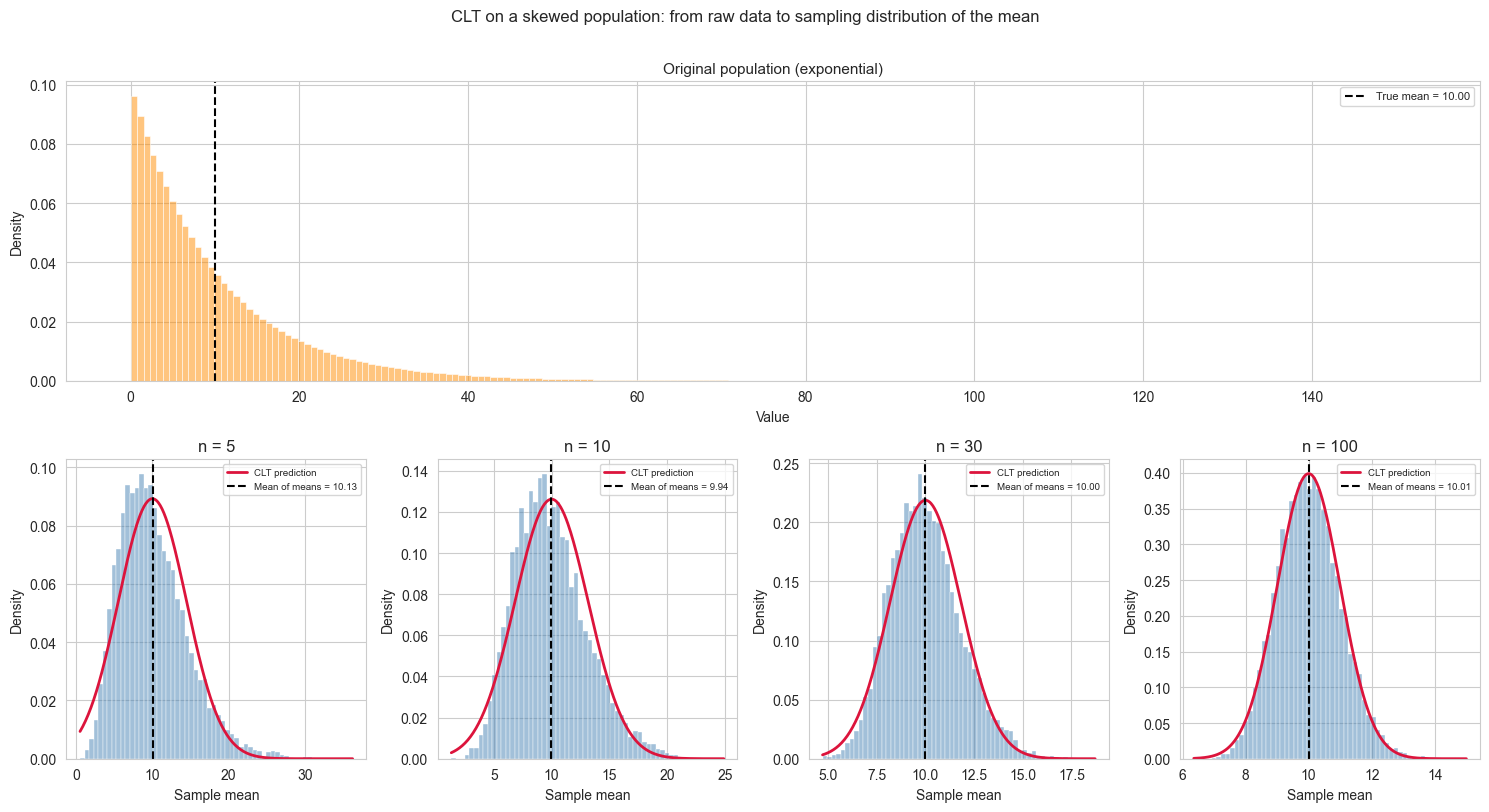

In [9]:
skewed_population = rng.exponential(scale=10, size=pop_size)
skewed_pop_mean   = skewed_population.mean()
skewed_pop_std    = skewed_population.std(ddof=0)

sample_sizes_clt = [5, 10, 30, 100]
n_repeats        = 10_000

fig, axes = plt.subplots(2, len(sample_sizes_clt), figsize=(15, 8),
                         gridspec_kw={"height_ratios": [1, 1]})

# ── Top row: original population spanning all columns ─────────────
ax_top = fig.add_subplot(2, 1, 1)
sns.histplot(skewed_population, bins=200, stat="density",
             color="darkorange", alpha=0.5, ax=ax_top)
ax_top.axvline(skewed_pop_mean, color="black", linestyle="--", linewidth=1.5,
               label=f"True mean = {skewed_pop_mean:.2f}")
ax_top.set_title("Original population (exponential)", fontsize=11)
ax_top.set_xlabel("Value")
ax_top.set_ylabel("Density")
ax_top.legend(fontsize=8)

for ax in axes[0]:
    ax.remove()

# ── Bottom row: sampling distributions ───────────────────────────
for ax, sample_size in zip(axes[1], sample_sizes_clt):
    means = np.array([
        rng.choice(skewed_population, size=sample_size, replace=False).mean()
        for _ in range(n_repeats)
    ])

    mean_of_means  = means.mean()
    sem_skewed     = skewed_pop_std / np.sqrt(sample_size)
    x_range        = np.linspace(means.min(), means.max(), 300)

    sns.histplot(means, bins=60, stat="density",
                 color="steelblue", alpha=0.5, ax=ax)
    ax.plot(x_range,
            stats.norm.pdf(x_range, skewed_pop_mean, sem_skewed),
            color="crimson", linewidth=2, label="CLT prediction")
    ax.axvline(mean_of_means, color="black", linestyle="--", linewidth=1.5,
               label=f"Mean of means = {mean_of_means:.2f}")
    ax.set_title(f"n = {sample_size}")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

fig.suptitle("CLT on a skewed population: from raw data to sampling distribution of the mean",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In the $n = 5$ panel the CLT prediction curve appears shifted to the right relative to the peak of the histogram. This is not an error. 

For a skewed distribution, the **mean**, **median** and **mode** do not  coincide. The exponential distribution has its mode at zero and a long right tail that pulls the mean well above it. The CLT prediction is centred on the population mean, as it should be, but at small $n$ the sampling distribution inherits some of the asymmetry of the original population, so its peak (mode) sits to the left of its mean. The curve is correctly placed; it is the histogram that is not yet symmetric.

As $n$ increases the sampling distribution becomes progressively more symmetric, its mode converges toward its mean, and the apparent mismatch disappears. By $n = 100$ the agreement is essentially perfect. This convergence is precisely what the CLT guarantees.

## Bonus: Extreme Samples, False Positives and the Logic of Hypothesis Testing

We have established that the sampling distribution of the mean is predictable: if we draw many samples of size $n$ from our population, the sample means will follow a Gaussian distribution centred on $\mu$ with standard deviation ${\sigma/\sqrt{n}$.

But what about a single draw that lands far from the centre? Is it a sign that something unusual is happening, or just bad luck?

This question is at the heart of **hypothesis testing**. Before introducing any formal machinery, we can build the intuition directly from our simulation.

**The setup.**

Suppose we draw one sample of $n = 30$ from our population and compute the sample mean. We then ask: *how surprising is this result, given what we know about the sampling distribution?*

To answer this we define a threshold $\alpha$: the fraction of the sampling distribution we are willing to consider "surprisingly extreme". For example, $\alpha = 0.05$ means we flag any sample mean that falls in the outermost 5% of the distribution (2.5% in each tail). This is the origin of the familiar 95% confidence threshold.

**The critical insight.**

Even when we draw from exactly the same population - nothing has changed, there is no effect, no anomaly - roughly $\alpha \times 100$% of all sample means will fall in those tails by pure chance. These are **false positives**: results that look surprising but are simply the expected consequence of random sampling.

Setting $\alpha$ is therefore not a statement about truth. It is a deliberate choice about how often you are willing to be fooled by chance.

In [10]:
alpha    = 0.05
n        = 30
n_repeats = 10_000

sem = pop_std / np.sqrt(n)

# critical values: the boundaries of the tails
lower_bound = stats.norm.ppf(alpha / 2,       loc=pop_mean, scale=sem)
upper_bound = stats.norm.ppf(1 - alpha / 2,   loc=pop_mean, scale=sem)

# draw many samples and record which means fall in the tails
sample_means = np.array([
    rng.choice(population, size=n, replace=False).mean()
    for _ in range(n_repeats)
])

in_tail      = (sample_means < lower_bound) | (sample_means > upper_bound)
false_positive_rate = in_tail.mean() * 100

print(f"Alpha                        : {alpha}")
print(f"Lower bound                  : {lower_bound:.4f} cm")
print(f"Upper bound                  : {upper_bound:.4f} cm")
print(f"")
print(f"Simulated false positive rate: {false_positive_rate:.2f}%")
print(f"Expected false positive rate : {alpha * 100:.2f}%")

Alpha                        : 0.05
Lower bound                  : 166.4268 cm
Upper bound                  : 173.5817 cm

Simulated false positive rate: 4.81%
Expected false positive rate : 5.00%


The following visualization will help exaplain what happened.

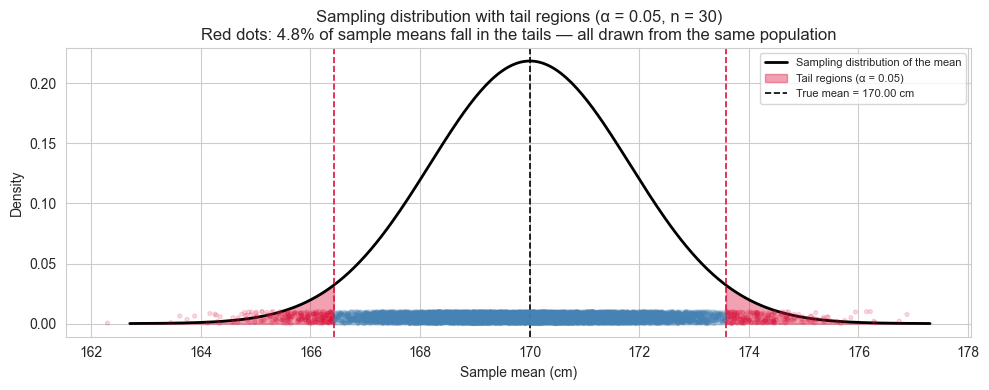

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

x_range = np.linspace(pop_mean - 4 * sem, pop_mean + 4 * sem, 300)

# sampling distribution
ax.plot(x_range, stats.norm.pdf(x_range, pop_mean, sem),
        color="black", linewidth=2, label="Sampling distribution of the mean")

# shade the tails
x_left  = np.linspace(pop_mean - 4 * sem, lower_bound, 200)
x_right = np.linspace(upper_bound, pop_mean + 4 * sem, 200)

ax.fill_between(x_left,  stats.norm.pdf(x_left,  pop_mean, sem),
                color="crimson", alpha=0.4, label=f"Tail regions (α = {alpha})")
ax.fill_between(x_right, stats.norm.pdf(x_right, pop_mean, sem),
                color="crimson", alpha=0.4)

# mark the bounds
ax.axvline(lower_bound, color="crimson", linestyle="--", linewidth=1.2)
ax.axvline(upper_bound, color="crimson", linestyle="--", linewidth=1.2)
ax.axvline(pop_mean,    color="black",   linestyle="--", linewidth=1.2,
           label=f"True mean = {pop_mean:.2f} cm")

# scatter a sample of observed means, coloured by whether they fall in the tail
in_tail_mask  = in_tail
colors_scatter = ["crimson" if t else "steelblue" for t in in_tail_mask]

ax.scatter(sample_means, 
           np.random.uniform(0, 0.01, size=n_repeats),
           c=colors_scatter, alpha=0.15, s=8, zorder=3)

ax.set_xlabel("Sample mean (cm)")
ax.set_ylabel("Density")
ax.set_title(f"Sampling distribution with tail regions (α = {alpha}, n = {n})\n"
             f"Red dots: {false_positive_rate:.1f}% of sample means fall in the tails "
             f"— all drawn from the same population")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**What this simulation tells us.**

Every red dot in the plot is a sample drawn from our population - the same population, with no anomaly, no intervention, no difference. Yet each of those means would be flagged as "surprising" under a threshold of $\alpha = 0.05$.

This is not a flaw in the method. It is the method being honest about its own limitations. When you set $\alpha = 0.05$ you are explicitly accepting that 1 in 20 experiments will produce a false alarm even when nothing is happening. Lowering $\alpha$ reduces false positives but makes it harder to detect real effects. This tension, between false positives and false negatives, is the fundamental trade-off of hypothesis testing, and it begins here, with the shape of the sampling distribution.